# DQN — Deep Q-Network

In [3]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import copy


## Neural Network

In [4]:
class DQNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DQNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


## DQN Agent

In [5]:
class DQNAgent:
    def __init__(self, env, learning_rate=0.001, gamma=0.97,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 memory_size=10000, batch_size=64, target_update=100):

        self.env = env
        self.n_states = env.size * env.size
        self.n_actions = 4
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update
        self.update_counter = 0

        self.state_size = self.n_states

        self.policy_net = DQNetwork(self.state_size, 128, self.n_actions)
        self.target_net = DQNetwork(self.state_size, 128, self.n_actions)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)

        self.memory = deque(maxlen=memory_size)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.best_reward = -float('inf')
        self.best_model = None

    def state_to_tensor(self, state):
        one_hot = np.zeros(self.state_size)
        one_hot[state] = 1
        return torch.FloatTensor(one_hot).unsqueeze(0)

    def choose_action(self, state, training=True):
        if training and np.random.random() < self.epsilon:
            return np.random.randint(0, self.n_actions)

        with torch.no_grad():
            state_tensor = self.state_to_tensor(state)
            q_values = self.policy_net(state_tensor)
            return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return 0

        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array([self.state_to_tensor(s).numpy() for s in states])).squeeze(1)
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(np.array([self.state_to_tensor(ns).numpy() for ns in next_states])).squeeze(1)
        dones = torch.FloatTensor(dones)

        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1))

        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q

        loss = nn.MSELoss()(current_q.squeeze(), target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.update_counter += 1
        if self.update_counter % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def evaluate(self, episodes=50):
        np.random.seed(69)
        random.seed(69)
        torch.manual_seed(69)

        rewards = []
        success_count = 0

        for _ in range(episodes):
            state, _ = self.env.reset()
            done = False
            total_reward = 0

            while not done:
                action = self.choose_action(state, training=False)
                state, reward, done, _, _ = self.env.step(action)
                total_reward += reward

            rewards.append(total_reward)
            if done and reward == 100:
                success_count += 1

        avg_reward = np.mean(rewards)
        success_rate = success_count / episodes * 100

        print(f"\nDQN Evaluation Results:")
        print(f"Average Reward: {avg_reward:.2f} +/- {np.std(rewards):.2f}")
        print(f"Success Rate: {success_rate:.1f}%")

        return avg_reward, success_rate

    def train(self, episodes=3000, verbose=True):
        episode_rewards = []
        episode_losses = []

        for episode in range(episodes):
            state, _ = self.env.reset()
            total_reward = 0
            done = False
            episode_loss = 0
            step = 0

            while not done and step < 200:
                action = self.choose_action(state, training=True)
                next_state, reward, done, _, _ = self.env.step(action)

                self.remember(state, action, reward, next_state, done)

                loss = self.replay()
                if loss > 0:
                    episode_loss += loss

                state = next_state
                total_reward += reward
                step += 1

            episode_rewards.append(total_reward)
            episode_losses.append(episode_loss / max(step, 1))
            self.decay_epsilon()

            if verbose and episode % 300 == 0 and episode > 0:
                train_avg = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else np.mean(episode_rewards)
                print(f"Episode {episode}: Training Avg = {train_avg:.2f}, Epsilon = {self.epsilon:.3f}")

                eval_reward, _ = self.evaluate(episodes=50)

                if eval_reward > self.best_reward:
                    self.best_reward = eval_reward
                    self.best_model = self.policy_net.state_dict().copy()
                    print(f"New best model saved! Evaluation Reward: {self.best_reward:.2f}")

        return episode_rewards, episode_losses

## Training

In [6]:
env = SmartAmbulanceEnv(size=20)
print("TRAINING DQN AGENT")
dqn_agent = DQNAgent(
    env,
    learning_rate=0.001,
    gamma=0.97,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    memory_size=10000,
    batch_size=64,
    target_update=100
)
dqn_rewards, dqn_losses = dqn_agent.train(episodes=3000)

TRAINING DQN AGENT
Episode 300: Training Avg = 27.72, Epsilon = 0.221

DQN Evaluation Results:
Average Reward: 49.20 +/- 14.09
Success Rate: 100.0%
New best model saved! Evaluation Reward: 49.20
Episode 600: Training Avg = 49.31, Epsilon = 0.049

DQN Evaluation Results:
Average Reward: 50.90 +/- 15.69
Success Rate: 100.0%
New best model saved! Evaluation Reward: 50.90
Episode 900: Training Avg = 52.77, Epsilon = 0.011

DQN Evaluation Results:
Average Reward: 50.60 +/- 16.80
Success Rate: 100.0%
Episode 1200: Training Avg = 51.31, Epsilon = 0.010

DQN Evaluation Results:
Average Reward: 47.90 +/- 20.77
Success Rate: 100.0%
Episode 1500: Training Avg = 50.31, Epsilon = 0.010

DQN Evaluation Results:
Average Reward: 46.60 +/- 18.60
Success Rate: 100.0%
Episode 1800: Training Avg = 47.83, Epsilon = 0.010

DQN Evaluation Results:
Average Reward: 51.70 +/- 15.81
Success Rate: 100.0%
New best model saved! Evaluation Reward: 51.70
Episode 2100: Training Avg = 53.93, Epsilon = 0.010

DQN Evalua

## Save Model

In [75]:
if dqn_agent.best_model is not None:
    torch.save(dqn_agent.best_model, 'best_dqn_model.pth')
    print(f"Best DQN model saved! Best reward: {dqn_agent.best_reward:.2f}")
else:
    torch.save(dqn_agent.policy_net.state_dict(), 'best_dqn_model.pth')
    print("DQN model saved as 'best_dqn_model.pth'")
print("Model saved successfully!")

Best DQN model saved! Best reward: 52.90
Model saved successfully!


## Learning Curve & Loss

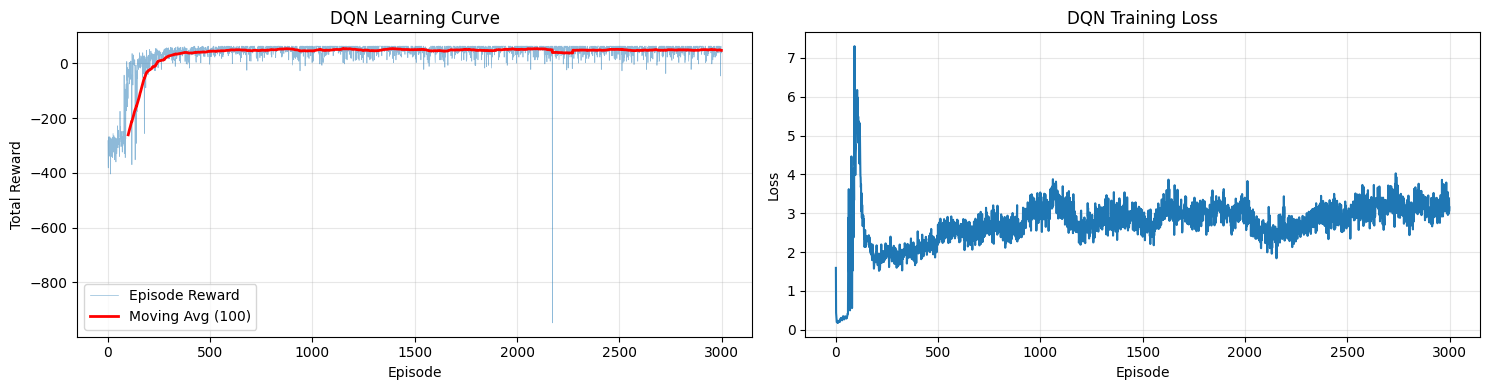

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(dqn_rewards, alpha=0.5, linewidth=0.5, label='Episode Reward')
window = 100
moving_avg = np.convolve(dqn_rewards, np.ones(window)/window, mode='valid')
axes[0].plot(range(window-1, len(dqn_rewards)), moving_avg, 'r-', linewidth=2, label=f'Moving Avg ({window})')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('DQN Learning Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(dqn_losses)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].set_title('DQN Training Loss')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dqn_training_curves.png', dpi=150)
plt.show()

#Load best model

In [76]:
best_dqn = DQNAgent(env)
best_dqn.policy_net.load_state_dict(torch.load('best_dqn_model.pth'))
best_dqn.target_net.load_state_dict(best_dqn.policy_net.state_dict())
print("Best DQN model loaded for evaluation")

Best DQN model loaded for evaluation


#EVALUATION - DQN

In [307]:
test_score, test_success = best_dqn.evaluate(episodes=50)
print(f"\n Loaded Model Performance:")
print(f"   Score: {test_score:.2f}")
print(f"   Success Rate: {test_success:.1f}%")

if dqn_agent.best_reward > 0:
    print(f"Best during training: {dqn_agent.best_reward:.2f}")
    if abs(test_score - dqn_agent.best_reward) < 2:
        print("Model matches training best")


DQN Evaluation Results:
Average Reward: 53.70 +/- 12.61
Success Rate: 100.0%

 Loaded Model Performance:
   Score: 53.70
   Success Rate: 100.0%
Best during training: 52.90
Model matches training best


## Trajectory Animation

CREATING DQN NAVIGATION VIDEO
Steps taken: 38
Reached hospital: True
Saved as 'dqn_navigation.mp4'


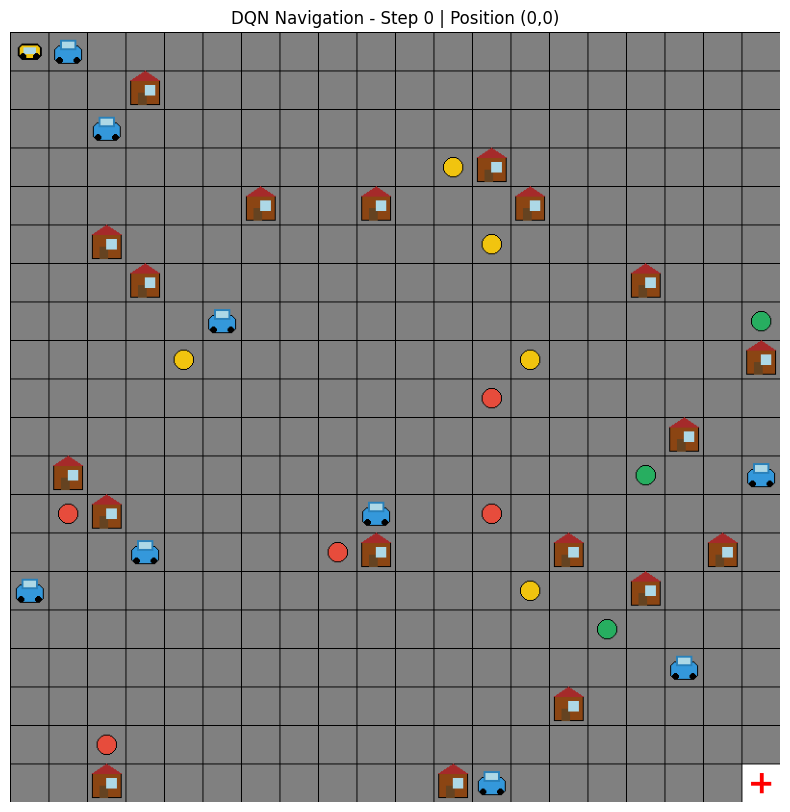

In [48]:
print("CREATING DQN NAVIGATION VIDEO")
state, _ = env.reset()
done = False
states_history = [state]
lights_history = [copy.deepcopy(env.traffic_lights)]
grid_history = [env._grid.copy()]

while not done and len(states_history) < 200:
    action = best_dqn.choose_action(state, training=False)
    state, reward, done, _, _ = env.step(action)

    states_history.append(state)
    lights_history.append(copy.deepcopy(env.traffic_lights))
    grid_history.append(env._grid.copy())

print(f"Steps taken: {len(states_history)-1}")
print(f"Reached hospital: {done}")

fig, ax = plt.subplots(figsize=(10, 10))

def update(frame):
    ax.clear()
    env._grid = grid_history[frame]
    frame_img = env.render_frame(states_history[frame], lights_history[frame])
    ax.imshow(frame_img)
    r, c = divmod(states_history[frame], env.cols)
    ax.set_title(f'DQN Navigation - Step {frame} | Position ({r},{c})')
    ax.axis('off')
    return ax

anim = FuncAnimation(fig, update, frames=len(states_history), interval=150, repeat=False)
anim.save('dqn_navigation.mp4', writer='ffmpeg', fps=8)
print("Saved as 'dqn_navigation.mp4'")

from IPython.display import Video
Video('dqn_navigation.mp4', embed=True, width=800, height=800)